In [15]:
def analyze_dataset_patterns(dataset_name='logical_deduction'):
    """Analyze patterns in a specific dataset across all models."""
    dataset_exps = exp_df[exp_df['dataset'] == dataset_name]
    
    if dataset_exps.empty:
        print(f"No experiments found for dataset: {dataset_name}")
        return
    
    print(f"# Analysis of {dataset_name} dataset")
    print("=" * 80)
    
    for _, exp in dataset_exps.iterrows():
        model = exp['model_short']
        print(f"\n## Model: {model}")
        print(f"Train Accuracy: {exp['train_accuracy']:.1f}%")
        print(f"Test Accuracy: {exp['test_accuracy']:.1f}%")
        print(f"Probe AUC: {exp['probe_auc']:.3f}" if exp['probe_auc'] else "Probe AUC: N/A")
        
        # Load train generations to analyze
        train_path = os.path.join(exp['path'], 'data', 'train_generations.pkl')
        if os.path.exists(train_path):
            with open(train_path, 'rb') as f:
                train_gens = pickle.load(f)
            
            # Analyze correct predictions only (what probes are trained on)
            correct_preds = [g for g in train_gens if g['pred_answer'] == g['correct_answer']]
            
            from collections import Counter
            
            # Distribution of correct predictions
            correct_dist = Counter(g['correct_answer'] for g in correct_preds)
            total_dist = Counter(g['correct_answer'] for g in train_gens)
            
            print(f"\nTrain set analysis:")
            print(f"  Total examples: {len(train_gens)}")
            print(f"  Correct predictions: {len(correct_preds)} ({len(correct_preds)/len(train_gens)*100:.1f}%)")
            print(f"  Label distribution (all): {dict(total_dist)}")
            print(f"  Label distribution (correct only): {dict(correct_dist)}")
            
            # Check if we have both classes in correct predictions
            if len(correct_dist) < 2:
                print(f"  ⚠️  WARNING: Only {list(correct_dist.keys())} class(es) in correct predictions!")
                print(f"     This would cause probe training to fail or produce meaningless results.")
            
            # Calculate class-wise accuracy
            for label in total_dist:
                label_total = sum(1 for g in train_gens if g['correct_answer'] == label)
                label_correct = sum(1 for g in train_gens if g['correct_answer'] == label and g['pred_answer'] == label)
                if label_total > 0:
                    print(f"  Accuracy for '{label}': {label_correct}/{label_total} ({label_correct/label_total*100:.1f}%)")
        
        # Check test distribution too
        test_path = os.path.join(exp['path'], 'data', 'test_generations.pkl')
        if os.path.exists(test_path):
            with open(test_path, 'rb') as f:
                test_gens = pickle.load(f)
            
            test_dist = Counter(g['correct_answer'] for g in test_gens)
            print(f"\nTest set analysis:")
            print(f"  Total examples: {len(test_gens)}")
            print(f"  Label distribution: {dict(test_dist)}")
    
    print("\n" + "=" * 80)
    print("Summary: Low AUC scores in logical_deduction might be due to:")
    print("1. Imbalanced label distributions")
    print("2. Models having very different accuracies for 'yes' vs 'no' answers")
    print("3. The probe being trained on a biased subset (only correct predictions)")
    print("4. The reasoning patterns for logical deduction not being linearly separable")

# Analyze logical deduction by default
analyze_dataset_patterns('logical_deduction')

# You can also check other datasets
print("\n\nOther datasets available for analysis:")
for dataset in exp_df['dataset'].unique():
    print(f"  - {dataset}")

# Analysis of logical_deduction dataset

## Model: Gemma-2B
Train Accuracy: 61.0%
Test Accuracy: 58.0%
Probe AUC: 0.328

Train set analysis:
  Total examples: 100
  Correct predictions: 61 (61.0%)
  Label distribution (all): {'yes': 40, 'no': 60}
  Label distribution (correct only): {'yes': 33, 'no': 28}
  Accuracy for 'yes': 33/40 (82.5%)
  Accuracy for 'no': 28/60 (46.7%)

Test set analysis:
  Total examples: 100
  Label distribution: {'no': 75, 'yes': 25}

## Model: Gemma-9B
Train Accuracy: 92.0%
Test Accuracy: 87.0%
Probe AUC: 0.692

Train set analysis:
  Total examples: 100
  Correct predictions: 92 (92.0%)
  Label distribution (all): {'no': 70, 'yes': 30}
  Label distribution (correct only): {'no': 62, 'yes': 30}
  Accuracy for 'no': 62/70 (88.6%)
  Accuracy for 'yes': 30/30 (100.0%)

Test set analysis:
  Total examples: 100
  Label distribution: {'no': 61, 'yes': 39}

## Model: Qwen_Qwen2.5-7B-Inst
Train Accuracy: 87.0%
Test Accuracy: 90.0%
Probe AUC: 0.186

Train set analysis:


### Explore Specific Dataset Patterns

This section helps identify patterns in specific datasets (e.g., why logical_deduction has low AUC scores).

In [16]:
# Create a dropdown to select experiment
from ipywidgets import interact, Dropdown, IntSlider, HTML
from IPython.display import display, Markdown

# Create experiment selection options
exp_options = []
for _, exp in exp_df.iterrows():
    if 'train_gen' in exp['status'] or 'test_gen' in exp['status']:
        label = f"{exp['model_short']} - {exp['dataset']} (Train: {exp['train_accuracy']:.1f}%, Test: {exp['test_accuracy']:.1f}%)"
        exp_options.append((label, exp['path']))

def explore_generations(exp_path, split='train', num_examples=5, show_incorrect_only=False):
    """Explore generations for a specific experiment."""
    # Load the generations
    gen_path = os.path.join(exp_path, 'data', f'{split}_generations.pkl')
    
    if not os.path.exists(gen_path):
        print(f"No {split} generations found at: {gen_path}")
        return
    
    with open(gen_path, 'rb') as f:
        generations = pickle.load(f)
    
    if not generations:
        print(f"No generations in the {split} set")
        return
    
    # Extract model and dataset info
    path_parts = Path(exp_path).parts
    model = dataset = "unknown"
    for i, part in enumerate(path_parts):
        if part == 'experiments' and i + 2 < len(path_parts):
            model = path_parts[i + 1]
            dataset = path_parts[i + 2]
            break
    
    # Filter if requested
    if show_incorrect_only:
        generations = [g for g in generations if g.get('pred_answer') != g.get('correct_answer')]
        if not generations:
            print("No incorrect predictions found!")
            return
    
    # Calculate stats
    total = len(generations)
    correct = sum(1 for g in generations if g.get('pred_answer') == g.get('correct_answer'))
    accuracy = correct / total * 100 if total > 0 else 0
    
    # Get label distribution
    from collections import Counter
    correct_dist = Counter(g.get('correct_answer', 'N/A') for g in generations)
    pred_dist = Counter(g.get('pred_answer', 'N/A') for g in generations)
    
    print(f"### Experiment: {model_names.get(model, model)} on {dataset}")
    print(f"**Split**: {split}")
    print(f"**Total examples**: {total}")
    print(f"**Accuracy**: {accuracy:.1f}% ({correct}/{total} correct)")
    print(f"**Correct answer distribution**: {dict(correct_dist)}")
    print(f"**Predicted answer distribution**: {dict(pred_dist)}")
    print(f"\nShowing {min(num_examples, len(generations))} examples:\n")
    print("-" * 80)
    
    # Show examples
    for i, gen in enumerate(generations[:num_examples]):
        correct_ans = gen.get('correct_answer', 'N/A')
        pred_ans = gen.get('pred_answer', 'N/A')
        is_correct = pred_ans == correct_ans
        
        print(f"\n**Example {i+1}** {'✓' if is_correct else '✗'}")
        
        # Show question if available
        if 'question' in gen:
            print(f"**Question**: {gen['question'][:200]}{'...' if len(gen.get('question', '')) > 200 else ''}")
        
        # Show input if available
        if 'input' in gen:
            print(f"**Input**: {gen['input'][:200]}{'...' if len(gen.get('input', '')) > 200 else ''}")
        
        print(f"**Correct Answer**: {correct_ans}")
        print(f"**Predicted Answer**: {pred_ans}")
        
        # Show response
        response = gen.get('response', gen.get('generated_text', 'N/A'))
        if isinstance(response, str):
            # Truncate very long responses
            if len(response) > 500:
                response = response[:500] + "..."
            print(f"**Response**: {response}")
        
        # Show additional metadata if available
        if 'category' in gen:
            print(f"**Category**: {gen['category']}")
        if 'success' in gen:
            print(f"**Steering Success**: {gen['success']}")
        
        print("-" * 80)

# Create interactive widget
if exp_options:
    interact(explore_generations,
             exp_path=Dropdown(options=exp_options, description='Experiment:', style={'description_width': '100px'}),
             split=Dropdown(options=['train', 'test'], value='train', description='Split:'),
             num_examples=IntSlider(min=1, max=20, value=5, description='# Examples:'),
             show_incorrect_only=Dropdown(options=[('All', False), ('Incorrect Only', True)], 
                                        value=False, description='Filter:'))
else:
    print("No experiments with generation data found!")

interactive(children=(Dropdown(description='Experiment:', options=(('Gemma-2B - anachronisms (Train: 83.0%, Te…

# Post-Hoc Reasoning Experiment Analysis

This notebook provides interactive analysis of steering experiments with language models.

In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Experiment Data

In [3]:
def load_json_safe(filepath: str) -> Optional[Any]:
    """Safely load JSON file."""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except:
        return None

def load_pickle_safe(filepath: str) -> Optional[Any]:
    """Safely load pickle file."""
    try:
        with open(filepath, 'rb') as f:
            return pickle.load(f)
    except:
        return None

def find_experiment_dirs(cache_dir: str = 'cache') -> List[str]:
    """Find all experiment directories in cache."""
    experiment_dirs = []
    base_dir = os.path.join(cache_dir, 'experiments') if not cache_dir.endswith('experiments') else cache_dir
    
    if not os.path.exists(base_dir):
        return []
    
    for root, dirs, files in os.walk(base_dir):
        if 'data' in dirs or 'metadata' in dirs:
            experiment_dirs.append(root)
    
    return experiment_dirs

# Find all experiments
exp_dirs = find_experiment_dirs('cache')
print(f"Found {len(exp_dirs)} experiment directories")

Found 51 experiment directories


## 2. Parse Experiment Results

In [4]:
def calculate_accuracy(results: List[Dict]) -> float:
    """Calculate accuracy from generation results."""
    if not results:
        return 0.0
    correct = sum(1 for r in results if r.get('pred_answer') == r.get('correct_answer'))
    return correct / len(results) * 100

def analyze_steering_results(steering_dir: str) -> Dict[float, Dict[str, Dict]]:
    """Analyze all steering results in a directory."""
    steering_data = defaultdict(lambda: {'yes': None, 'no': None})
    
    if not os.path.exists(steering_dir):
        return {}
    
    for filename in os.listdir(steering_dir):
        if filename.startswith('steering_alpha_') and filename.endswith('.pkl'):
            parts = filename.replace('steering_alpha_', '').replace('.pkl', '').rsplit('_', 1)
            if len(parts) == 2:
                try:
                    alpha = float(parts[0])
                    direction = parts[1]
                    
                    results = load_pickle_safe(os.path.join(steering_dir, filename))
                    if results:
                        total = len(results)
                        successes = sum(1 for r in results if r.get('success', False))
                        
                        # Count parsing categories
                        parsed = sum(1 for r in results if r.get('category', '') != 'unparsed')
                        unparsed = sum(1 for r in results if r.get('category', '') == 'unparsed')
                        failures = sum(1 for r in results if r.get('category', '') == 'failure')
                        
                        # Success rate calculations
                        success_rate_all = successes / total if total > 0 else 0
                        success_rate_parsed = successes / parsed if parsed > 0 else 0
                        
                        steering_data[alpha][direction] = {
                            'total': total,
                            'successes': successes,
                            'failures': failures,
                            'parsed': parsed,
                            'unparsed': unparsed,
                            'success_rate_all': success_rate_all,
                            'success_rate_parsed': success_rate_parsed,
                            'parse_rate': parsed / total if total > 0 else 0
                        }
                except ValueError:
                    continue
    
    return dict(steering_data)

def analyze_experiment(exp_path: str) -> Dict[str, Any]:
    """Analyze a single experiment directory."""
    result = {
        'path': exp_path,
        'model': 'unknown',
        'dataset': 'unknown',
        'train_accuracy': None,
        'test_accuracy': None,
        'probe_auc': None,
        'best_layer': None,
        'steering_results': {},
        'status': []
    }
    
    # Extract model and dataset from path
    path_parts = Path(exp_path).parts
    for i, part in enumerate(path_parts):
        if part == 'experiments' and i + 2 < len(path_parts):
            result['model'] = path_parts[i + 1]
            result['dataset'] = path_parts[i + 2]
            break
    
    # Load and analyze generations
    train_gen_path = os.path.join(exp_path, 'data', 'train_generations.pkl')
    test_gen_path = os.path.join(exp_path, 'data', 'test_generations.pkl')
    
    train_results = load_pickle_safe(train_gen_path)
    test_results = load_pickle_safe(test_gen_path)
    
    if train_results:
        result['train_accuracy'] = calculate_accuracy(train_results)
        result['status'].append('train_gen')
    
    if test_results:
        result['test_accuracy'] = calculate_accuracy(test_results)
        result['status'].append('test_gen')
    
    # Load probe results
    auc_paths = [
        os.path.join(exp_path, 'probes', 'caa-single-layer', 'auc_scores.json'),
        os.path.join(exp_path, 'probes', 'auc_scores.json')
    ]
    
    for auc_path in auc_paths:
        auc_scores = load_json_safe(auc_path)
        if auc_scores:
            if isinstance(auc_scores, dict):
                scores = list(auc_scores.values())
                layers = list(auc_scores.keys())
                if scores:
                    max_idx = np.argmax(scores)
                    result['probe_auc'] = float(scores[max_idx])
                    result['best_layer'] = int(layers[max_idx])
            else:
                result['probe_auc'] = float(max(auc_scores))
                result['best_layer'] = int(np.argmax(auc_scores))
            result['status'].append('probes')
            break
    
    # Analyze steering results
    steering_dir = os.path.join(exp_path, 'steering')
    result['steering_results'] = analyze_steering_results(steering_dir)
    if result['steering_results']:
        result['status'].append('steering')
    
    return result

In [5]:
# Analyze all experiments
all_results = []
for exp_dir in exp_dirs:
    result = analyze_experiment(exp_dir)
    if result['status']:
        all_results.append(result)

# Create DataFrame for easier analysis
exp_df = pd.DataFrame(all_results)
print(f"Analyzed {len(all_results)} experiments with data")
print(f"\nExperiment status breakdown:")
for status in ['train_gen', 'test_gen', 'probes', 'steering']:
    count = sum(1 for r in all_results if status in r['status'])
    print(f"  {status}: {count} experiments")

Analyzed 17 experiments with data

Experiment status breakdown:
  train_gen: 17 experiments
  test_gen: 17 experiments
  probes: 14 experiments
  steering: 17 experiments


## 3. Model Performance Overview

In [6]:
# Model name mapping for cleaner display
model_names = {
    'deepseek-ai_DeepSeek-R1-Distill-Qwen-1.5B': 'DeepSeek-1.5B',
    'google_gemma-2-2b-it': 'Gemma-2B',
    'google_gemma-2-9b-it': 'Gemma-9B'
}

exp_df['model_short'] = exp_df['model'].map(lambda x: model_names.get(x, x.split('/')[-1][:20]))

# Create summary table
summary_df = exp_df[['model_short', 'dataset', 'train_accuracy', 'test_accuracy', 'probe_auc', 'best_layer']].copy()
summary_df.columns = ['Model', 'Dataset', 'Train Acc', 'Test Acc', 'Probe AUC', 'Best Layer']
summary_df = summary_df.round({'Train Acc': 1, 'Test Acc': 1, 'Probe AUC': 3})
summary_df

,Model,Dataset,Train Acc,Test Acc,Probe AUC,Best Layer
0,Gemma-2B,anachronisms,83.0,82.0,0.893,14.0
1,Gemma-2B,sports_understanding,77.0,75.0,0.672,13.0
2,Gemma-2B,logical_deduction,61.0,58.0,0.328,13.0
3,Gemma-9B,anachronisms,88.0,90.0,0.948,23.0
4,Gemma-9B,sports_understanding,92.0,91.0,0.837,29.0
5,Gemma-9B,logical_deduction,92.0,87.0,0.692,23.0
6,Qwen_Qwen2.5-7B-Inst,anachronisms,88.0,84.0,0.954,21.0
7,Qwen_Qwen2.5-7B-Inst,sports_understanding,88.0,85.0,0.795,18.0
8,Qwen_Qwen2.5-7B-Inst,logical_deduction,87.0,90.0,0.186,14.0
9,Qwen_Qwen2.5-7B-Inst,social_chemistry,90.0,93.0,0.931,20.0


## 4. Accuracy Visualization

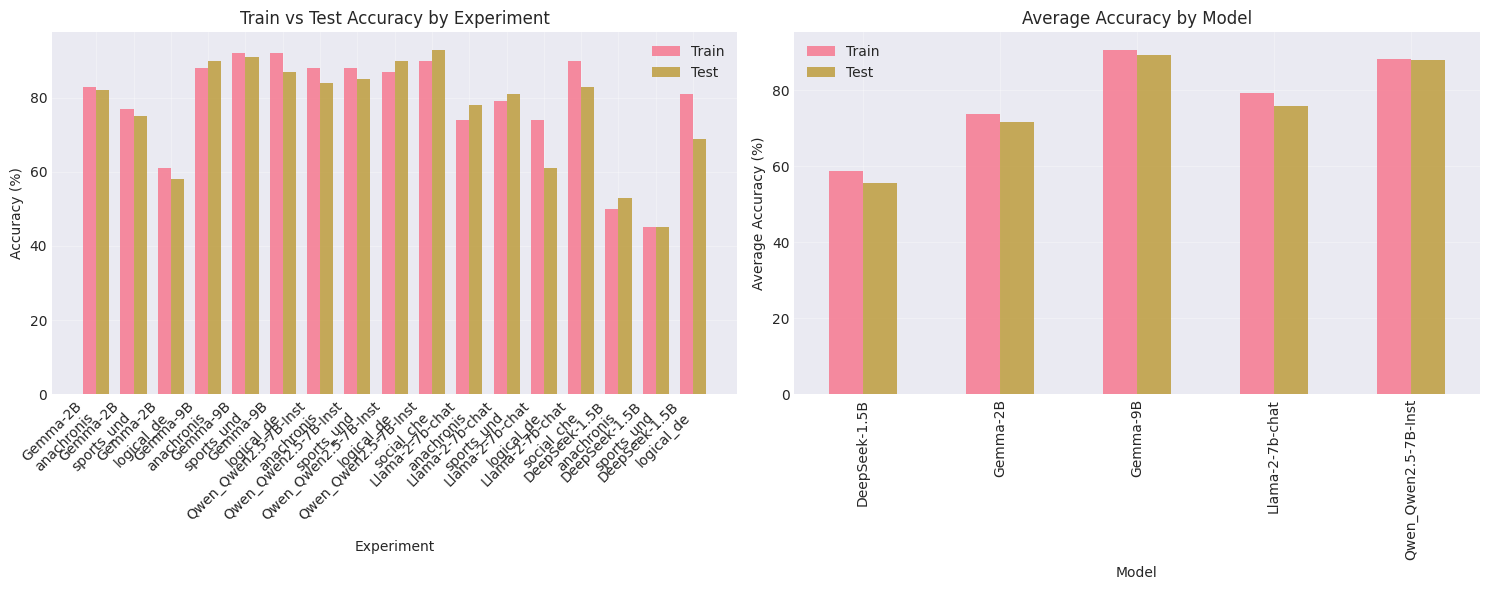

In [7]:
# Plot train vs test accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
acc_data = exp_df[exp_df['train_accuracy'].notna()].copy()
x = np.arange(len(acc_data))
width = 0.35

ax1.bar(x - width/2, acc_data['train_accuracy'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, acc_data['test_accuracy'], width, label='Test', alpha=0.8)
ax1.set_xlabel('Experiment')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Train vs Test Accuracy by Experiment')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{row['model_short']}\n{row['dataset'][:10]}" for _, row in acc_data.iterrows()], 
                    rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy by model
model_acc = exp_df.groupby('model_short')[['train_accuracy', 'test_accuracy']].mean()
model_acc.plot(kind='bar', ax=ax2, alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('Average Accuracy (%)')
ax2.set_title('Average Accuracy by Model')
ax2.legend(['Train', 'Test'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Probe Performance Analysis

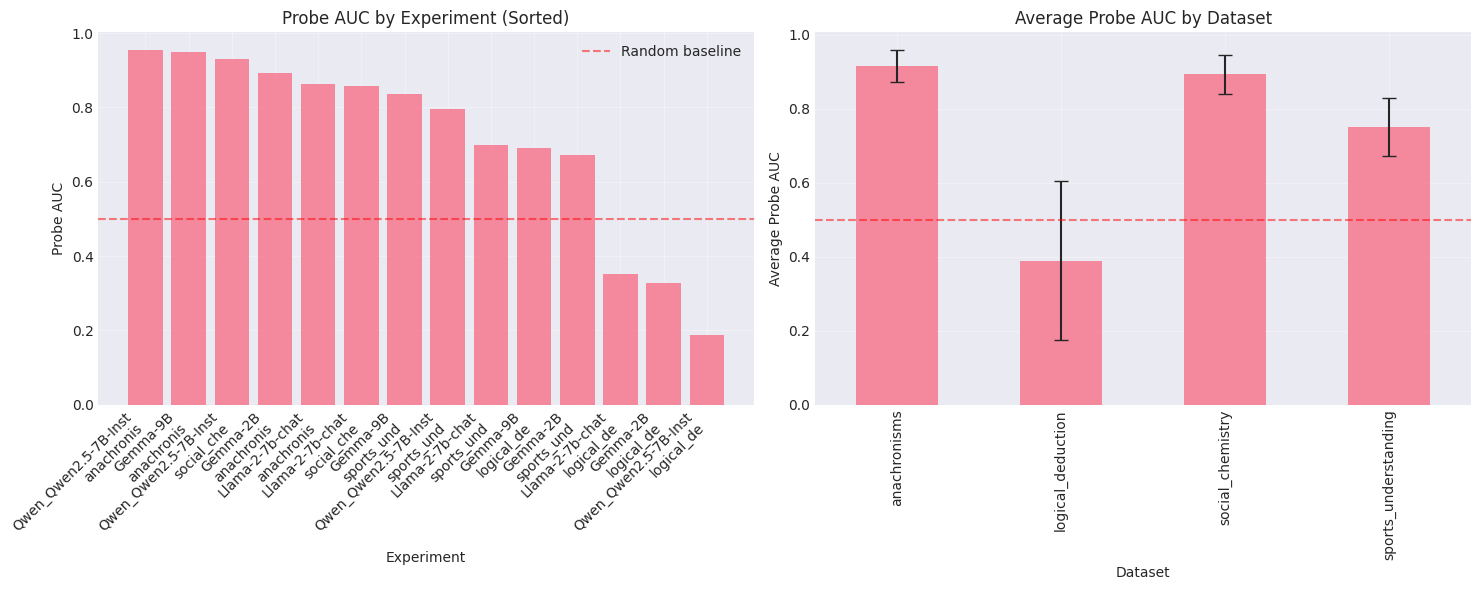

<Figure size 1000x600 with 0 Axes>

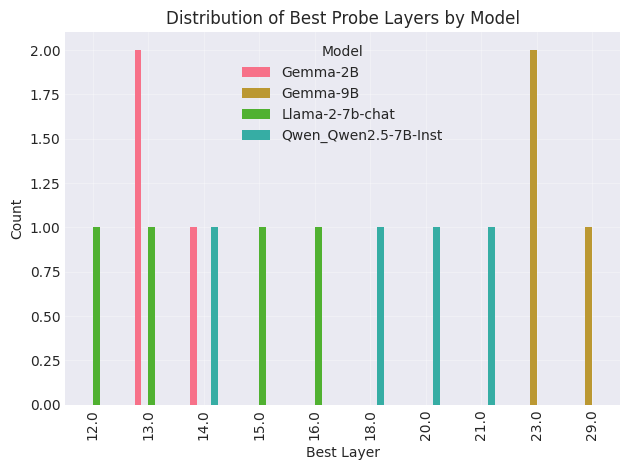

In [8]:
# Probe AUC visualization
probe_data = exp_df[exp_df['probe_auc'].notna()].copy()

if not probe_data.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # AUC by experiment
    probe_data = probe_data.sort_values('probe_auc', ascending=False)
    ax1.bar(range(len(probe_data)), probe_data['probe_auc'], alpha=0.8)
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('Probe AUC')
    ax1.set_title('Probe AUC by Experiment (Sorted)')
    ax1.set_xticks(range(len(probe_data)))
    ax1.set_xticklabels([f"{row['model_short']}\n{row['dataset'][:10]}" for _, row in probe_data.iterrows()],
                        rotation=45, ha='right')
    ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Random baseline')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # AUC by dataset
    dataset_auc = probe_data.groupby('dataset')['probe_auc'].agg(['mean', 'std', 'count'])
    dataset_auc['mean'].plot(kind='bar', ax=ax2, yerr=dataset_auc['std'], alpha=0.8, capsize=5)
    ax2.set_xlabel('Dataset')
    ax2.set_ylabel('Average Probe AUC')
    ax2.set_title('Average Probe AUC by Dataset')
    ax2.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Best layer distribution
    plt.figure(figsize=(10, 6))
    probe_data.groupby('model_short')['best_layer'].value_counts().unstack(fill_value=0).T.plot(kind='bar')
    plt.xlabel('Best Layer')
    plt.ylabel('Count')
    plt.title('Distribution of Best Probe Layers by Model')
    plt.legend(title='Model')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No probe data available for visualization")

## 6. Steering Analysis

In [9]:
# Extract steering data into a flat structure
steering_records = []
for _, exp in exp_df.iterrows():
    if exp['steering_results']:
        for alpha, directions in exp['steering_results'].items():
            for direction, data in directions.items():
                if data:
                    record = {
                        'model': exp['model_short'],
                        'dataset': exp['dataset'],
                        'alpha': alpha,
                        'direction': direction,
                        'success_rate_all': data['success_rate_all'],
                        'success_rate_parsed': data['success_rate_parsed'],
                        'parse_rate': data['parse_rate'],
                        'total': data['total'],
                        'parsed': data['parsed'],
                        'unparsed': data['unparsed']
                    }
                    steering_records.append(record)

steering_df = pd.DataFrame(steering_records)
print(f"Found {len(steering_df)} steering conditions")

Found 331 steering conditions


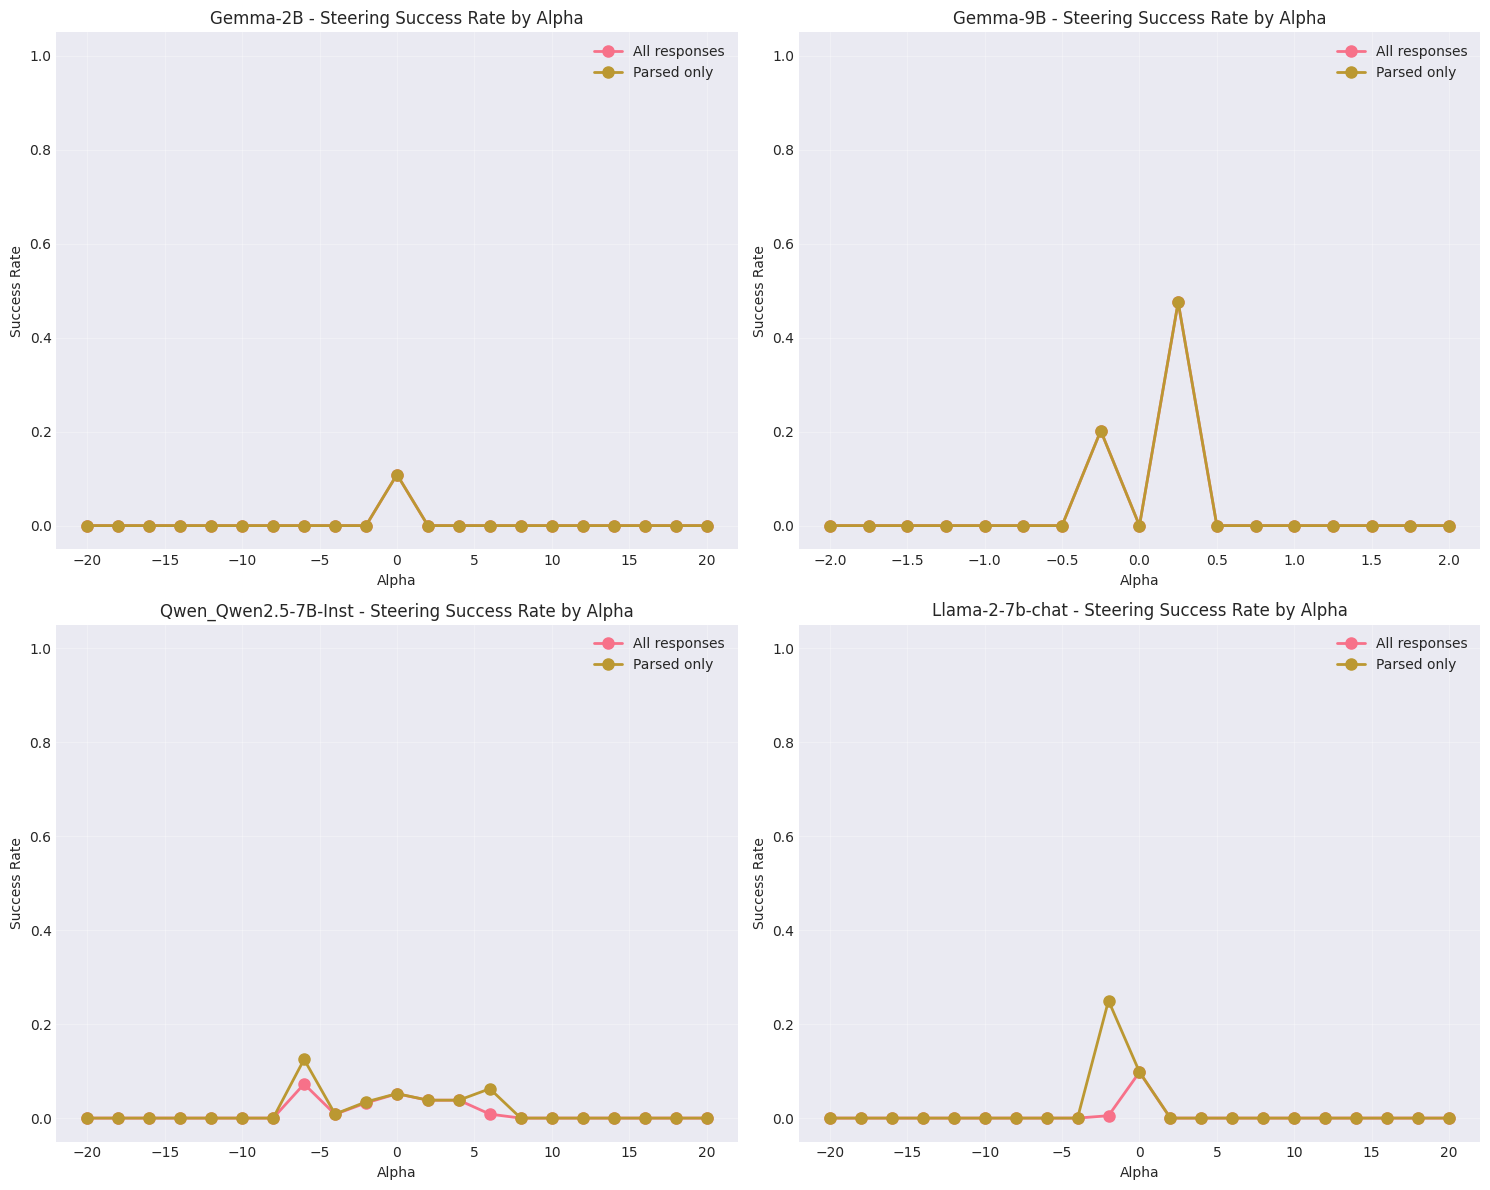

In [10]:
# Steering success rate by alpha
if not steering_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    # Plot for each model
    models = steering_df['model'].unique()
    for idx, model in enumerate(models[:4]):
        model_data = steering_df[steering_df['model'] == model]
        
        # Group by alpha and calculate mean success rates
        alpha_stats = model_data.groupby('alpha')[['success_rate_all', 'success_rate_parsed']].mean()
        
        ax = axes[idx]
        alpha_stats.plot(ax=ax, marker='o', markersize=8, linewidth=2)
        ax.set_xlabel('Alpha')
        ax.set_ylabel('Success Rate')
        ax.set_title(f'{model} - Steering Success Rate by Alpha')
        ax.legend(['All responses', 'Parsed only'])
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    
    # Hide unused subplots
    for idx in range(len(models), 4):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 7. Parsing Analysis

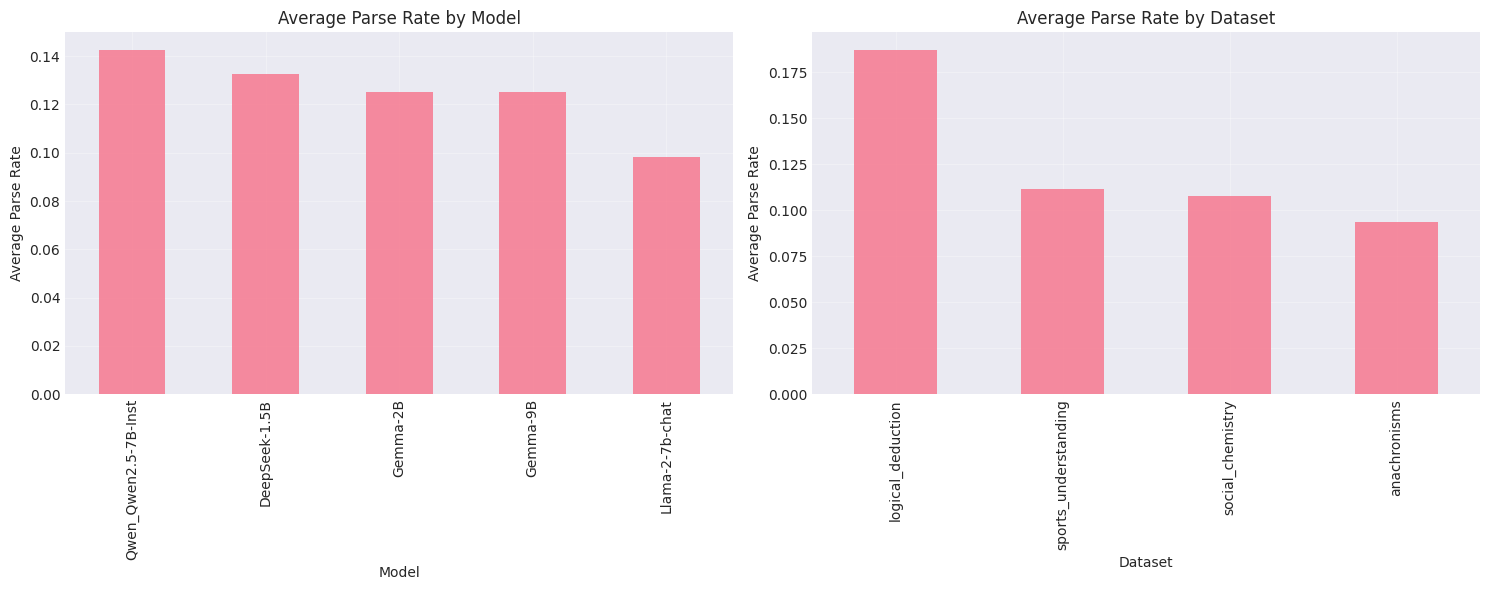

<Figure size 1000x600 with 0 Axes>

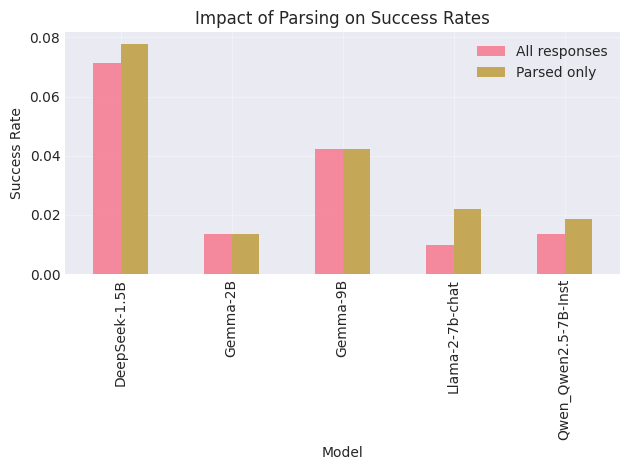

In [11]:
# Parsing statistics
if not steering_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Parse rate by model
    model_parse = steering_df.groupby('model')['parse_rate'].mean().sort_values(ascending=False)
    model_parse.plot(kind='bar', ax=ax1, alpha=0.8)
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Average Parse Rate')
    ax1.set_title('Average Parse Rate by Model')
    ax1.grid(True, alpha=0.3)
    
    # Parse rate by dataset
    dataset_parse = steering_df.groupby('dataset')['parse_rate'].mean().sort_values(ascending=False)
    dataset_parse.plot(kind='bar', ax=ax2, alpha=0.8)
    ax2.set_xlabel('Dataset')
    ax2.set_ylabel('Average Parse Rate')
    ax2.set_title('Average Parse Rate by Dataset')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Parsing impact on success rate
    plt.figure(figsize=(10, 6))
    impact_data = steering_df.groupby('model')[['success_rate_all', 'success_rate_parsed']].mean()
    impact_data['difference'] = impact_data['success_rate_parsed'] - impact_data['success_rate_all']
    impact_data[['success_rate_all', 'success_rate_parsed']].plot(kind='bar', alpha=0.8)
    plt.xlabel('Model')
    plt.ylabel('Success Rate')
    plt.title('Impact of Parsing on Success Rates')
    plt.legend(['All responses', 'Parsed only'])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Heatmap Analysis

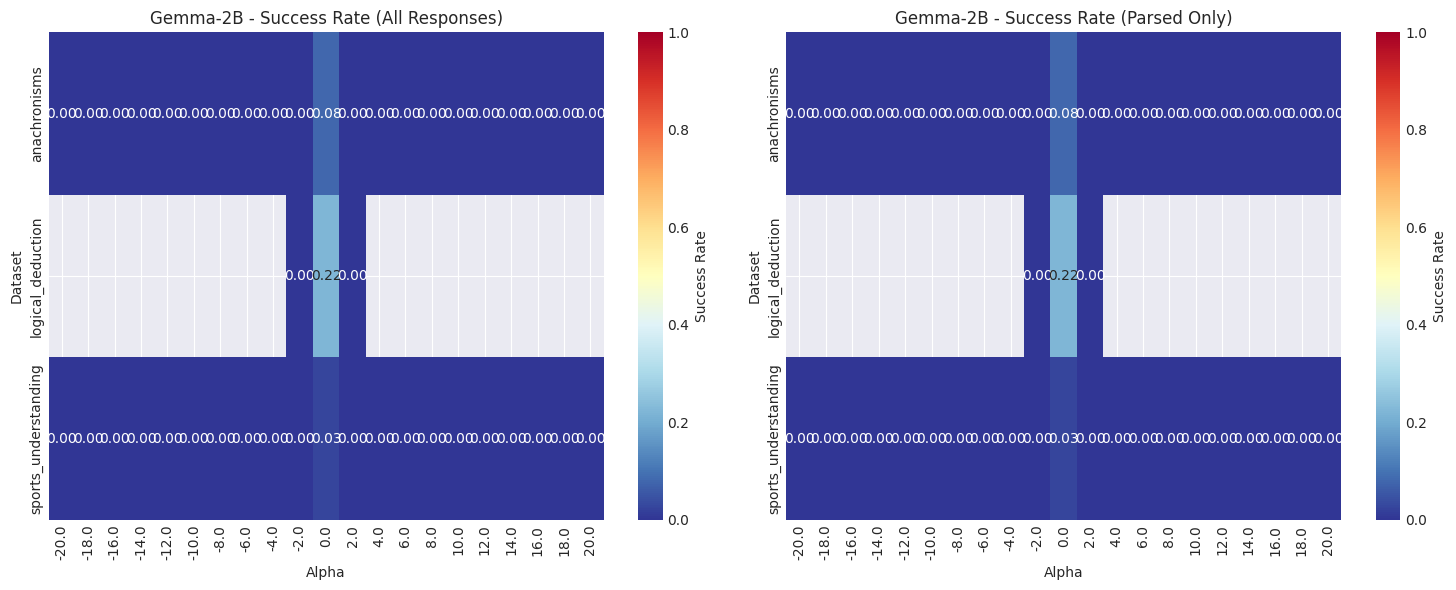

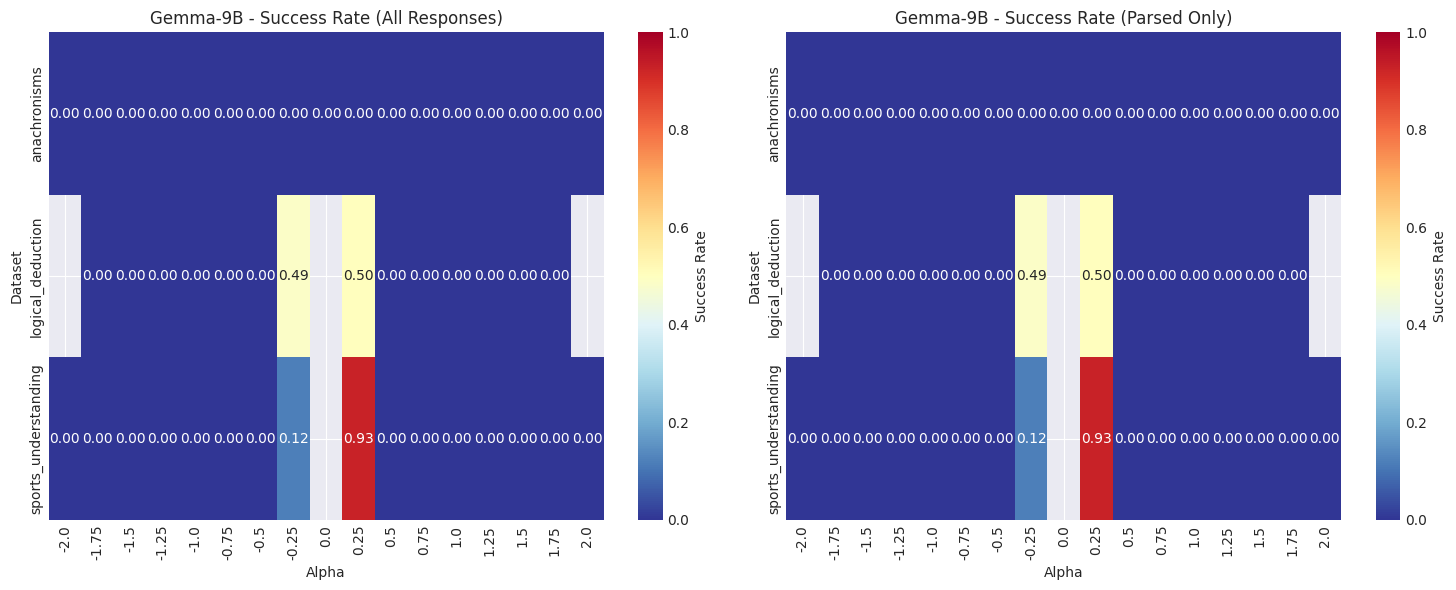

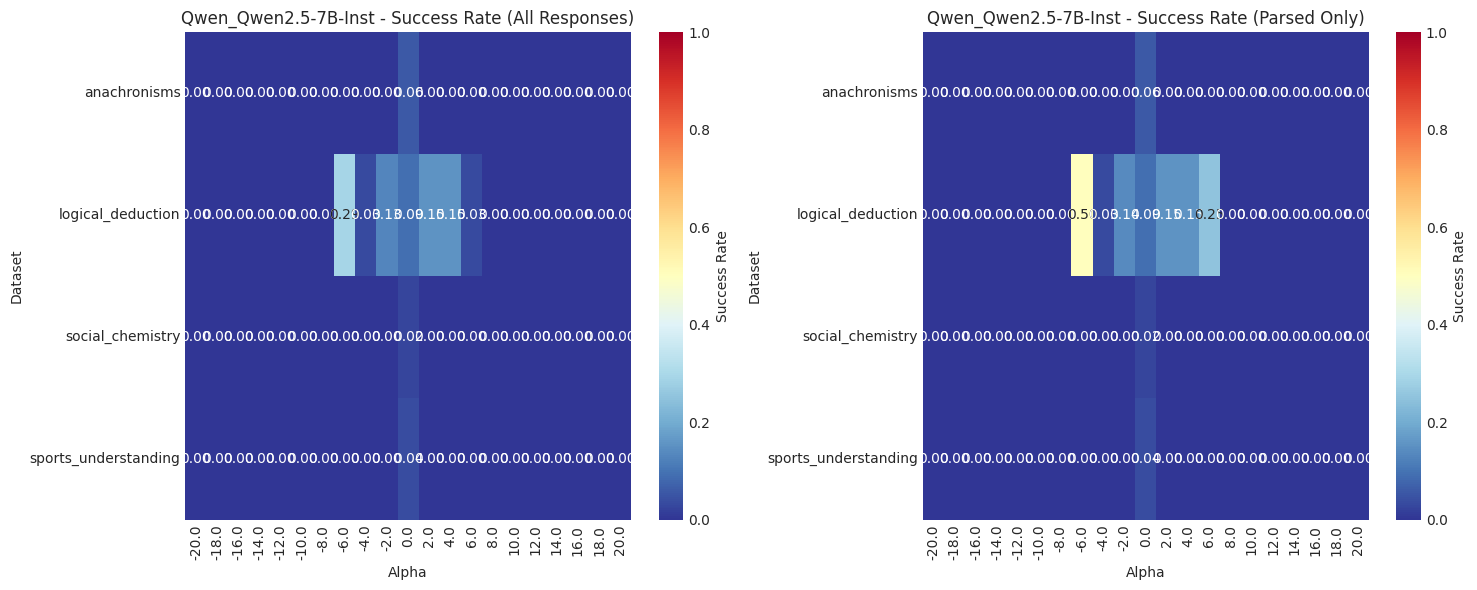

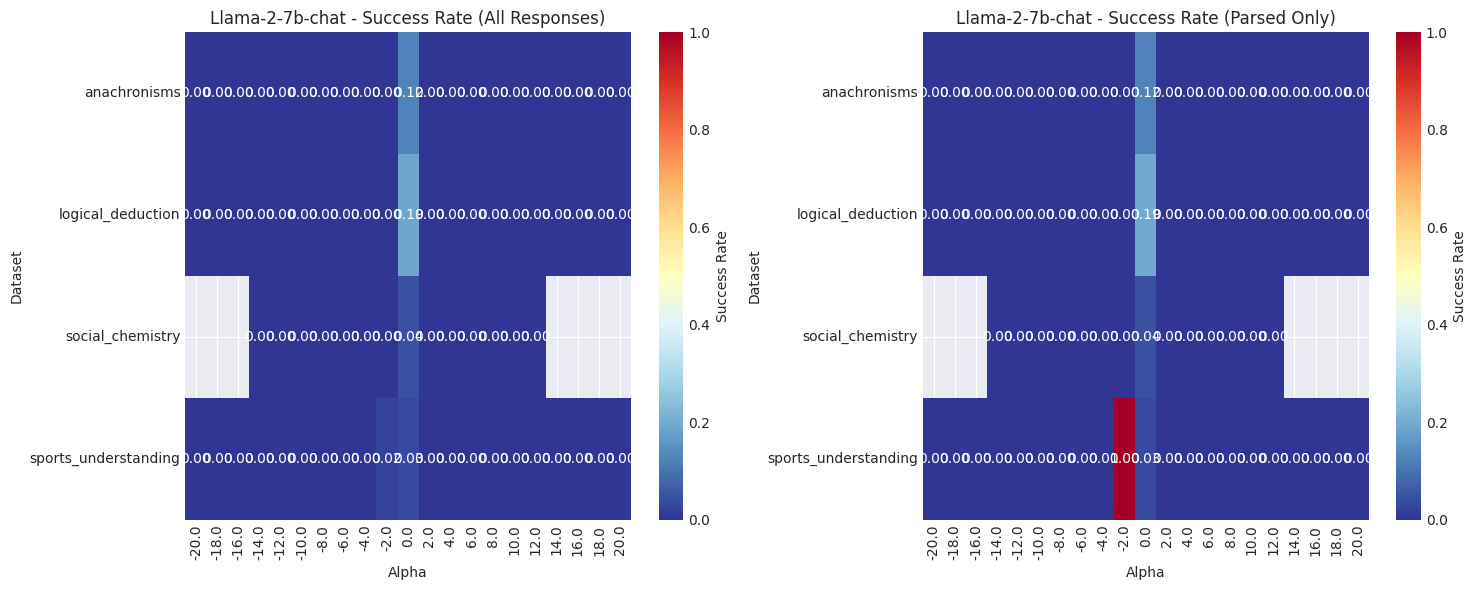

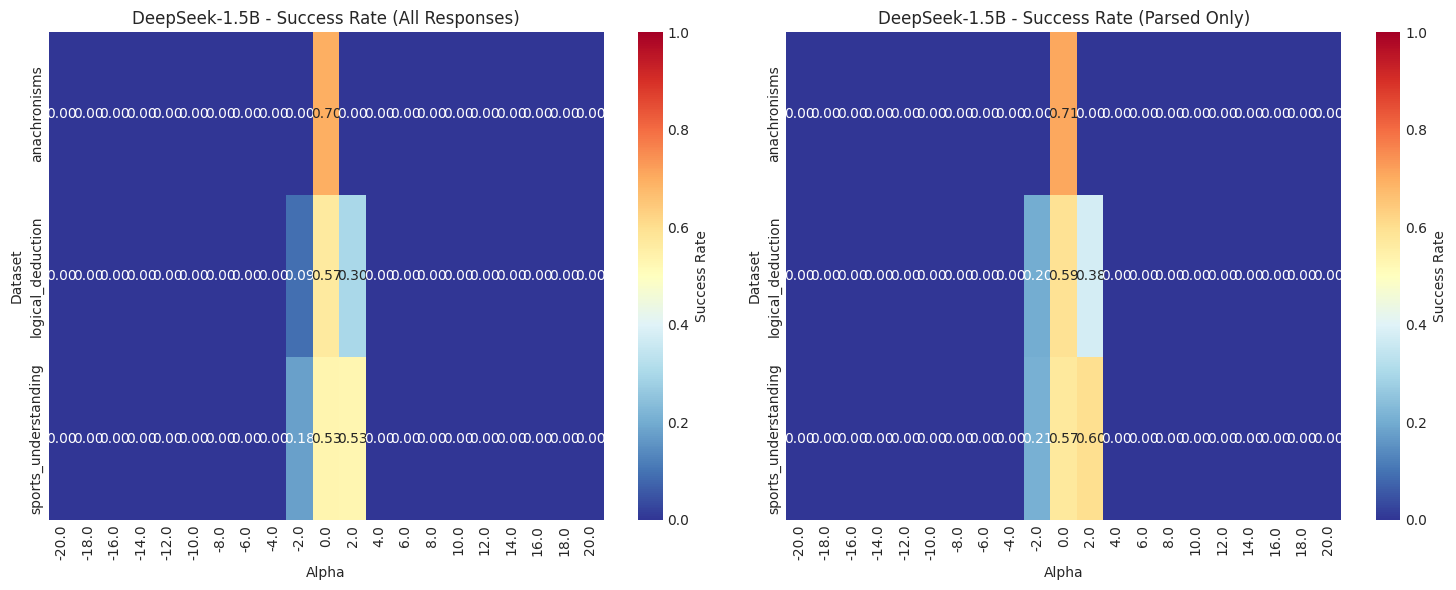

In [12]:
# Create heatmaps for steering success
if not steering_df.empty:
    for model in steering_df['model'].unique():
        model_data = steering_df[steering_df['model'] == model]
        
        # Pivot for heatmap
        pivot_all = model_data.pivot_table(
            values='success_rate_all',
            index='dataset',
            columns='alpha',
            aggfunc='mean'
        )
        
        pivot_parsed = model_data.pivot_table(
            values='success_rate_parsed',
            index='dataset',
            columns='alpha',
            aggfunc='mean'
        )
        
        if not pivot_all.empty:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # All responses heatmap
            sns.heatmap(pivot_all, annot=True, fmt='.2f', cmap='RdYlBu_r', 
                       vmin=0, vmax=1, ax=ax1, cbar_kws={'label': 'Success Rate'})
            ax1.set_title(f'{model} - Success Rate (All Responses)')
            ax1.set_xlabel('Alpha')
            ax1.set_ylabel('Dataset')
            
            # Parsed only heatmap
            sns.heatmap(pivot_parsed, annot=True, fmt='.2f', cmap='RdYlBu_r',
                       vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'Success Rate'})
            ax2.set_title(f'{model} - Success Rate (Parsed Only)')
            ax2.set_xlabel('Alpha')
            ax2.set_ylabel('Dataset')
            
            plt.tight_layout()
            plt.show()

## 9. Statistical Summary

In [13]:
# Generate comprehensive statistics
print("=" * 80)
print("COMPREHENSIVE EXPERIMENT STATISTICS")
print("=" * 80)

# Model statistics
for model in exp_df['model_short'].unique():
    model_exps = exp_df[exp_df['model_short'] == model]
    print(f"\n{model}:")
    
    # Accuracy stats
    train_accs = model_exps['train_accuracy'].dropna()
    test_accs = model_exps['test_accuracy'].dropna()
    if not train_accs.empty:
        print(f"  Train accuracy: {train_accs.mean():.1f}% (±{train_accs.std():.1f}%)")
    if not test_accs.empty:
        print(f"  Test accuracy: {test_accs.mean():.1f}% (±{test_accs.std():.1f}%)")
    
    # Probe stats
    probe_aucs = model_exps['probe_auc'].dropna()
    if not probe_aucs.empty:
        print(f"  Probe AUC: {probe_aucs.mean():.3f} (±{probe_aucs.std():.3f})")
        print(f"  Best probe AUC: {probe_aucs.max():.3f}")
    
    # Steering stats
    if not steering_df.empty:
        model_steering = steering_df[steering_df['model'] == model]
        if not model_steering.empty:
            success_all = model_steering['success_rate_all']
            success_parsed = model_steering['success_rate_parsed']
            parse_rates = model_steering['parse_rate']
            
            print(f"  Steering conditions tested: {len(model_steering)}")
            print(f"  Conditions with >0% success: {(success_all > 0).sum()}")
            print(f"  Average success rate (all): {success_all.mean():.1%}")
            print(f"  Average success rate (parsed): {success_parsed.mean():.1%}")
            print(f"  Average parse rate: {parse_rates.mean():.1%}")

# Dataset statistics
print("\n" + "=" * 80)
print("DATASET STATISTICS")
print("=" * 80)

for dataset in exp_df['dataset'].unique():
    dataset_exps = exp_df[exp_df['dataset'] == dataset]
    print(f"\n{dataset}:")
    
    test_accs = dataset_exps['test_accuracy'].dropna()
    probe_aucs = dataset_exps['probe_auc'].dropna()
    
    if not test_accs.empty:
        print(f"  Average test accuracy: {test_accs.mean():.1f}%")
    if not probe_aucs.empty:
        print(f"  Average probe AUC: {probe_aucs.mean():.3f}")
        print(f"  Best probe AUC: {probe_aucs.max():.3f}")

COMPREHENSIVE EXPERIMENT STATISTICS

Gemma-2B:
  Train accuracy: 73.7% (±11.4%)
  Test accuracy: 71.7% (±12.3%)
  Probe AUC: 0.631 (±0.285)
  Best probe AUC: 0.893
  Steering conditions tested: 48
  Conditions with >0% success: 5
  Average success rate (all): 1.4%
  Average success rate (parsed): 1.4%
  Average parse rate: 12.5%

Gemma-9B:
  Train accuracy: 90.7% (±2.3%)
  Test accuracy: 89.3% (±2.1%)
  Probe AUC: 0.826 (±0.128)
  Best probe AUC: 0.948
  Steering conditions tested: 48
  Conditions with >0% success: 4
  Average success rate (all): 4.2%
  Average success rate (parsed): 4.2%
  Average parse rate: 12.5%

Qwen_Qwen2.5-7B-Inst:
  Train accuracy: 88.2% (±1.3%)
  Test accuracy: 88.0% (±4.2%)
  Probe AUC: 0.717 (±0.360)
  Best probe AUC: 0.954
  Steering conditions tested: 88
  Conditions with >0% success: 12
  Average success rate (all): 1.4%
  Average success rate (parsed): 1.9%
  Average parse rate: 14.3%

Llama-2-7b-chat:
  Train accuracy: 79.2% (±7.5%)
  Test accuracy: 75.

## 10. Export Results

In [14]:
# Export summary data to CSV
summary_df.to_csv('experiment_summary.csv', index=False)
print("Saved experiment summary to experiment_summary.csv")

if not steering_df.empty:
    steering_df.to_csv('steering_results.csv', index=False)
    print("Saved steering results to steering_results.csv")
    
    # Create pivot table for easy viewing
    steering_pivot = steering_df.pivot_table(
        values=['success_rate_all', 'success_rate_parsed', 'parse_rate'],
        index=['model', 'dataset'],
        columns='alpha',
        aggfunc='mean'
    )
    steering_pivot.to_csv('steering_pivot.csv')
    print("Saved steering pivot table to steering_pivot.csv")

Saved experiment summary to experiment_summary.csv
Saved steering results to steering_results.csv
Saved steering pivot table to steering_pivot.csv


## 11. Explore Individual Generations

This section allows you to explore the actual generated responses for any experiment.